In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

### directory with N_eff results

In [4]:
neff_results_dir = '../output/results/'

### Loop over directories to find all parameter points and load results

In [5]:
mass_dirs = []
mass_charge_dirs = []

for name in os.listdir(neff_results_dir):
    if os.path.isdir(os.path.join(neff_results_dir, name)):
        mass_dirs.append(os.path.join(neff_results_dir, name))


for md in mass_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mass_charge_dirs.append(os.path.join(md, name))
    
    

In [6]:
num_param_points = len(mass_charge_dirs)

masses = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)


for (i, mcd) in enumerate(mass_charge_dirs):
    result_file = os.path.join(mcd, 'result.npz')
    if os.path.exists(result_file):
        result = np.load(result_file)

        masses[i] = result['m_mcp']
        charges[i] = result['Q']
        N_eff[i] = result['N_eff_bsm']
        Delta_N_eff[i] = result['Delta_Neff']
        Delta_N_eff_dso[i] = result['DNeff_dso']

### Plots

In [12]:
unique_masses = np.unique(masses)

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()

for um in unique_masses:
    charges_um = charges[np.where(masses == um)]
    N_eff_um = N_eff[np.where(masses == um)]
    Delta_N_eff_um = Delta_N_eff[np.where(masses == um)]
    Delta_N_eff_dso_um = Delta_N_eff_dso[np.where(masses == um)]

    sort_order = charges_um.argsort()

    result_um = np.array([
        charges_um[sort_order], 
        N_eff_um[sort_order],
        Delta_N_eff_um[sort_order],
        Delta_N_eff_dso_um[sort_order]
    ])

    dne_I = interp1d(
        charges_um[sort_order], 
        Delta_N_eff_dso_um[sort_order], 
        bounds_error=False, 
        fill_value=(Delta_N_eff_dso_um[sort_order][0], Delta_N_eff_dso_um[sort_order][-1])
    )

    N_eff_results_dict = N_eff_results_dict | {um:   result_um}   
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um: dne_I}

In [15]:
list(N_eff_results_dict.keys())

[0.1, 0.3, 1.0, 10.0, 31.0, 100.0]

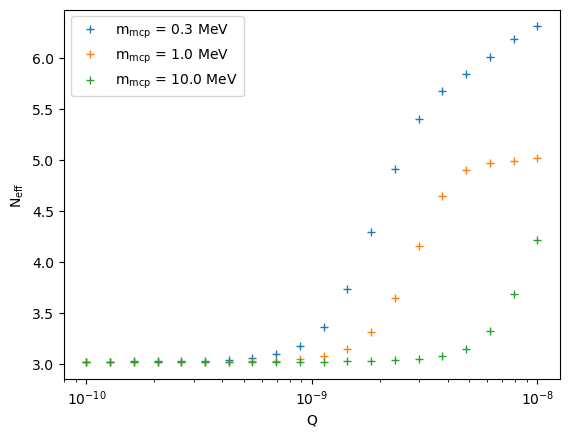

In [19]:
plt.plot(N_eff_results_dict[0.3][0], N_eff_results_dict[0.3][1], linestyle='none', marker='+', label=r'm$_{\rm mcp}$ = 0.3 MeV')

plt.plot(N_eff_results_dict[1.0][0], N_eff_results_dict[1.0][1], linestyle='none', marker='+', label=r'm$_{\rm mcp}$ = 1.0 MeV')

plt.plot(N_eff_results_dict[10.0][0], N_eff_results_dict[10.0][1], linestyle='none', marker='+', label=r'm$_{\rm mcp}$ = 10.0 MeV')


plt.xscale('log')

plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend()
plt.show()

In [38]:
def get_DNeff_constraint_RHS(delta_neff_Interp, constraint):
    return lambda Q: delta_neff_Interp(Q) - constraint

def find_Q_DNeff_constraint(delta_neff_Interp, constraint):
    Q_min = delta_neff_Interp.x[0]
    Q_max = delta_neff_Interp.x[-1]    
    
    try:
        constraint_res = root_scalar(
         get_DNeff_constraint_RHS(delta_neff_Interp, constraint),
         bracket=(Q_min, Q_max),
         x0=2e-9
    )
        return constraint_res.root
    except:
        return np.nan

In [21]:
find_Q_DNeff_constraint(Delta_N_eff_interp_dict[0.3], 0.06)

6.495951605341244e-10

In [22]:
find_Q_DNeff_constraint(Delta_N_eff_interp_dict[1.0], 0.06)

1.116823257493209e-09

In [25]:
find_Q_DNeff_constraint(Delta_N_eff_interp_dict[10.0], 0.06)

3.8191788788528606e-09

In [28]:
Delta_N_eff_interp_dict[100.0].x

array([8.00000000e-10, 9.68130133e-10, 1.17159494e-09, 1.41782046e-09,
       1.71579339e-09, 2.07638911e-09, 2.51276858e-09, 3.04085872e-09,
       3.67993370e-09, 4.45331838e-09, 5.38923965e-09, 6.52185663e-09,
       7.89250741e-09, 9.55121781e-09, 1.15585272e-08, 1.39876981e-08,
       1.69273901e-08, 2.04848955e-08, 2.47900558e-08, 3.00000000e-08])

In [59]:
Q_Neff_0_06_constraint = np.zeros(len(unique_masses))
Q_Neff_0_027_constraint = np.zeros(len(unique_masses))

for (i, mass) in enumerate(unique_masses):
    Q_Neff_0_06_constraint[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass], 0.06)
    Q_Neff_0_027_constraint[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass], 0.027)

In [60]:
Q_Neff_0_027_constraint

array([3.74277224e-10, 4.94963020e-10, 8.41167744e-10, 2.91836912e-09,
       5.42929972e-09, 1.08011285e-08])

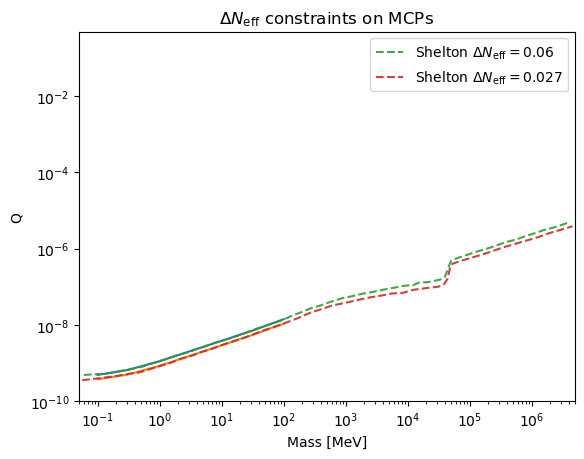

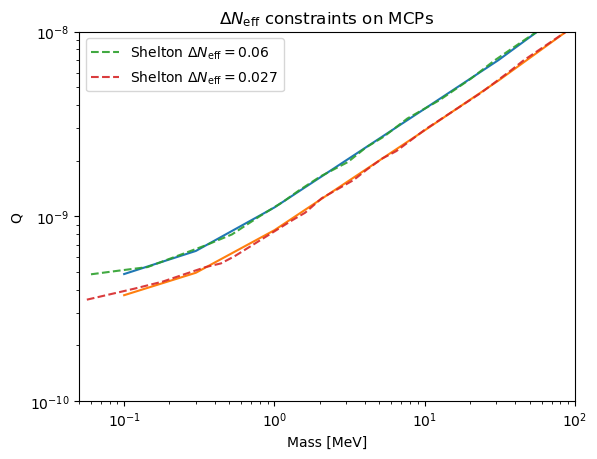

In [70]:
plt.plot(unique_masses, Q_Neff_0_06_constraint)
plt.plot(unique_masses, Q_Neff_0_027_constraint)

plt.plot(*shelton_neff_const_0_06, linestyle='dashed', alpha=0.9, label=r'Shelton $\Delta N_{\rm eff} = 0.06$')
plt.plot(*shelton_neff_const_0_027, linestyle='dashed', alpha=0.9, label=r'Shelton $\Delta N_{\rm eff} = 0.027$')

plt.yscale('log')
plt.xscale('log')
plt.xlim(5e-2, 5e6)
plt.ylim(1e-10, 5e-1)

plt.xlabel('Mass [MeV]')
plt.ylabel('Q')
plt.title(r'$\Delta N_{\rm eff}$ constraints on MCPs')

plt.legend()

plt.show()



plt.plot(unique_masses, Q_Neff_0_06_constraint)
plt.plot(unique_masses, Q_Neff_0_027_constraint)

plt.plot(*shelton_neff_const_0_06, linestyle='dashed', alpha=0.9, label=r'Shelton $\Delta N_{\rm eff} = 0.06$')
plt.plot(*shelton_neff_const_0_027, linestyle='dashed', alpha=0.9, label=r'Shelton $\Delta N_{\rm eff} = 0.027$')

plt.yscale('log')
plt.xscale('log')
plt.xlim(5e-2, 1e2)
plt.ylim(1e-10, 1e-8)

plt.xlabel('Mass [MeV]')
plt.ylabel('Q')
plt.title(r'$\Delta N_{\rm eff}$ constraints on MCPs')

plt.legend()

plt.show()